# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset details 79,354 phone contacts across 17 direct marketing campaigns from May 2008 to November 2010. The telemarketing calls promised attractive interest rates on long-term deposits and gathered demographic and financial details for each client. Ultimately, the dataset shows 8% success rate, with 6,499 customers subscribing.

Key Dataset Statistics

- Total Contacts: 79,354
- Total Campaigns: 17
- Timeline: May 2008 – November 2010
- Successful Subscriptions: 6,499
- Overall Success Rate: 8%

The interactions logged key socioeconomic and credit factors, including: employment status, job, marital status, education level, existing housing loans and personal debt.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [59]:
import pandas as pd

In [60]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [61]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [63]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [64]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

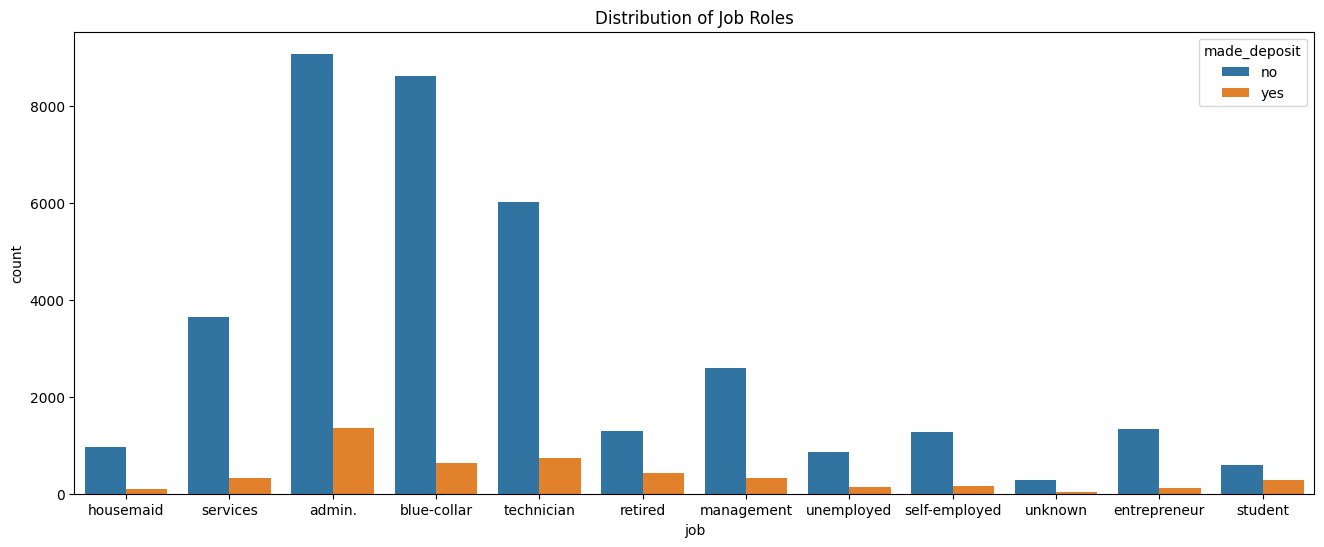

In [68]:
# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

df.rename(columns = {'y':'made_deposit'}, inplace = True)

plt.figure(figsize=(16,6))
sns.countplot(x='job', hue="made_deposit",data=df)
plt.title('Distribution of Job Roles')
plt.show()

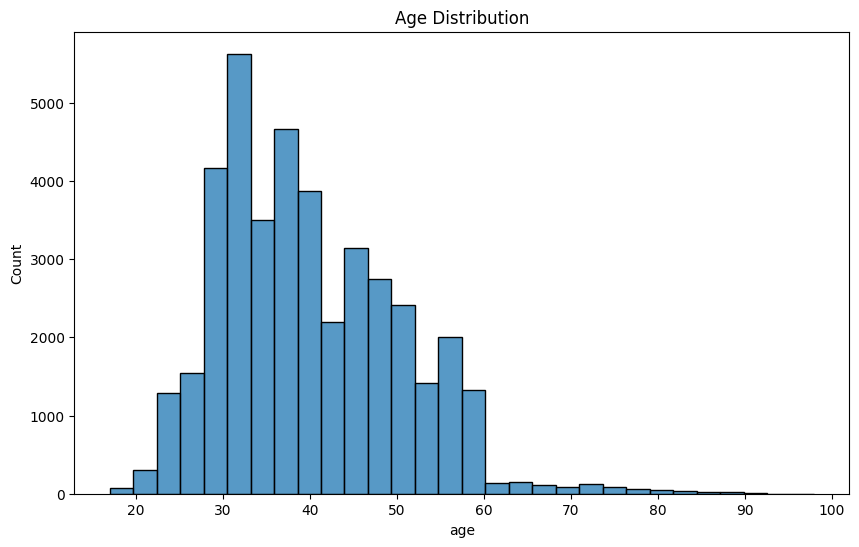

In [69]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.show()

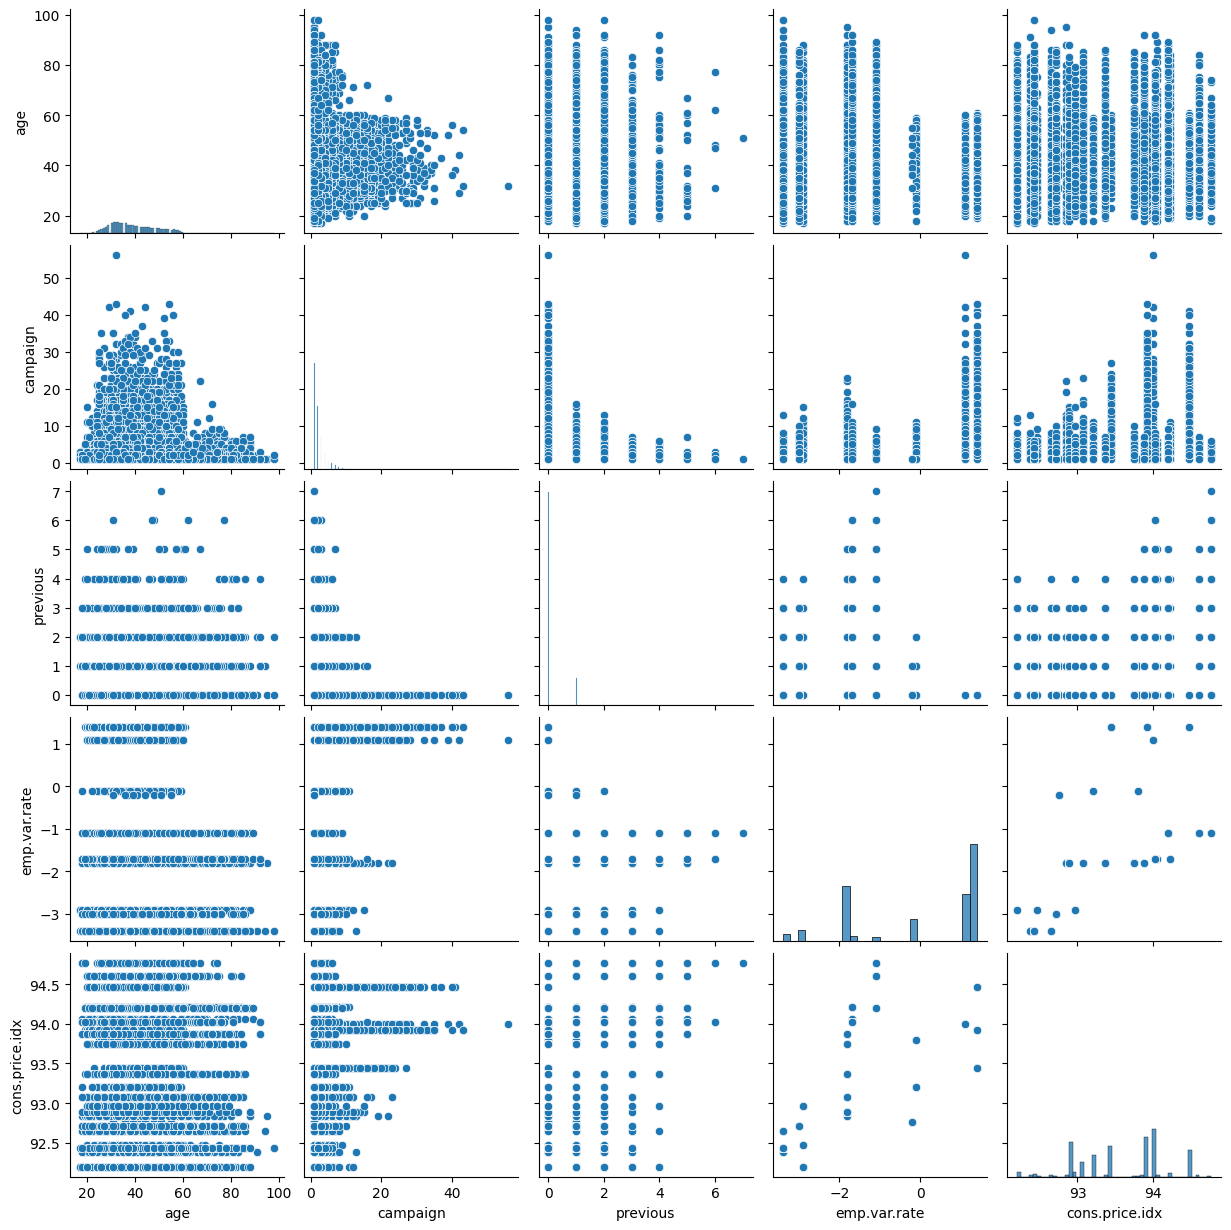

In [70]:
sns.pairplot(df[['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx']])
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [72]:
# Checking the distribution of the target variable
df['made_deposit'].value_counts(normalize=True)

made_deposit
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [73]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [74]:
# Encode categorical variables
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
for column in categorical_columns:
    df[column] = LabelEncoder().fit_transform(df[column])

In [75]:
# Feature scaling (if necessary)
scaler = StandardScaler()
numerical_columns = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [76]:
# Split data into features and target variable
X = df.drop('made_deposit', axis=1)
y = LabelEncoder().fit_transform(df['made_deposit'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [77]:
#train and evaluate the classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [78]:
#Check the Distribution of the Target Variable:

#Use value counts
df['made_deposit'].value_counts(normalize=True)

made_deposit
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [79]:
# Baseline Accuracy:
# Determine the accuracy of majority class prediction.

majority_class = df['made_deposit'].mode()[0]
baseline_accuracy = (df['made_deposit'] == majority_class).mean()
print(f"Baseline Accuracy: {baseline_accuracy:.2f}")

Baseline Accuracy: 0.89


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [80]:
#Scale the features to improve the performance of the model, especially for algorithms like Logistic Regression.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
#Fit the Logistic Regression Model:

#Initialize the Logistic Regression model and fit it on the training data.
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [82]:
# Perform predictions based on the test data using the trained model.

y_pred = model.predict(X_test_scaled)

print(y_pred)

[0 0 0 ... 0 1 0]


### Problem 9: Score the Model

What is the accuracy of your model?

In [83]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Evaluate the Model:

#Assess the model's performance using accuracy, confusion matrix, and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.91
Confusion Matrix:
[[7108  195]
 [ 544  391]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [84]:
# Initialize the models with default settings
logistic_model = LogisticRegression(random_state=42, max_iter=200)
knn_model = KNeighborsClassifier()
decision_tree_model = DecisionTreeClassifier(random_state=42)
svm_model = SVC(random_state=42)

In [85]:
# Train and Evaluate Models
# Dictionary to store results
import time

results = []

# Function to evaluate model
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    results.append([model_name, train_time, train_accuracy, test_accuracy])

# Evaluate Logistic Regression
evaluate_model(logistic_model, 'Logistic Regression', X_train, X_test, y_train, y_test)

# Evaluate KNN
evaluate_model(knn_model, 'KNN', X_train, X_test, y_train, y_test)

# Evaluate Decision Tree
evaluate_model(decision_tree_model, 'Decision Tree', X_train, X_test, y_train, y_test)

# Evaluate SVM
evaluate_model(svm_model, 'SVM', X_train, X_test, y_train, y_test)

In [86]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy'])

# Display the results
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.080536,0.910349,0.910415
1,KNN,0.001907,0.926646,0.896091
2,Decision Tree,0.082278,1.000000,0.889900
3,SVM,4.269015,0.910076,0.905681


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [87]:
from sklearn.model_selection import GridSearchCV

param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

param_grid_decision_tree = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# GridSearchCV for Logistic Regression
grid_search_log_reg = GridSearchCV(logistic_model, param_grid_log_reg, cv=5, scoring='accuracy')
grid_search_log_reg.fit(X_train, y_train)
print("Best parameters for Logistic Regression:", grid_search_log_reg.best_params_)

# GridSearchCV for KNN
grid_search_knn = GridSearchCV(knn_model, param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)
print("Best parameters for KNN:", grid_search_knn.best_params_)

# GridSearchCV for Decision Tree
grid_search_decision_tree = GridSearchCV(decision_tree_model, param_grid_decision_tree, cv=5, scoring='accuracy')
grid_search_decision_tree.fit(X_train, y_train)
print("Best parameters for Decision Tree:", grid_search_decision_tree.best_params_)

# GridSearchCV for SVM
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)
print("Best parameters for SVM:", grid_search_svm.best_params_)

Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}
Best parameters for KNN: {'n_neighbors': 9, 'weights': 'distance'}
Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_split': 10}
Best parameters for SVM: {'C': 10, 'kernel': 'rbf'}


In [88]:
# Retrieve the best estimators
best_log_reg = grid_search_log_reg.best_estimator_
best_knn = grid_search_knn.best_estimator_
best_decision_tree = grid_search_decision_tree.best_estimator_
best_svm = grid_search_svm.best_estimator_

# Calculate training and test accuracies for each tuned model
tuned_results = {}

tuned_results['Logistic Regression'] = {
    'Train Accuracy': best_log_reg.score(X_train, y_train),
    'Test Accuracy': best_log_reg.score(X_test, y_test)
}

tuned_results['KNN'] = {
    'Train Accuracy': best_knn.score(X_train, y_train),
    'Test Accuracy': best_knn.score(X_test, y_test)
}

tuned_results['Decision Tree'] = {
    'Train Accuracy': best_decision_tree.score(X_train, y_train),
    'Test Accuracy': best_decision_tree.score(X_test, y_test)
}

tuned_results['SVM'] = {
    'Train Accuracy': best_svm.score(X_train, y_train),
    'Test Accuracy': best_svm.score(X_test, y_test)
}

# Display the tuned results
tuned_results_df = pd.DataFrame.from_dict(tuned_results, orient='index')
display(tuned_results_df)

,Train Accuracy,Test Accuracy
Logistic Regression,0.911077,0.909565
KNN,1.000000,0.897791
Decision Tree,0.938179,0.907866
SVM,0.921730,0.910658


### Key Results

* The baseline accuracy was 0.89.
* The test accuracies were:
   * for Logistic Regression, they were the same before and after tuning, at 0.90.
   * for kNN, they also remained unchanged, at 0.90
   * for Decision Trees, there was a slight improvement, from 0.89 to 0.90.
   * for SVM, they were the same before and after tuning, at 0.91.
* SVM achieved the highest test accuracy (0.91) among all models.

##### Questions